# AI Support-Ticket Intelligence System

**Fine-grained customer-support intent routing, uncertainty handling, semantic retrieval and issue discovery.**

### Business problem
A digital support operation receives thousands of short customer queries. The system should:
1. route each query to the right specialist queue;
2. know when its routing confidence is too low and hand off to a human;
3. retrieve similar historical queries for agent context;
4. discover recurring issue families;
5. create an operational triage queue.

### Dataset
This notebook uses **BANKING77**, a standard customer-service intent benchmark with **13,083 English online-banking queries labelled across 77 fine-grained intents**.

Official source:
- 10,003 training queries
- 3,080 sealed test queries
- 77 intent classes
- Creative Commons Attribution 4.0

The original official test split is kept untouched until final evaluation.

### Demographics / privacy
BANKING77 contains **query text and intent labels only**. It does **not** provide age, sex, names, email addresses or other customer demographics, so none are invented or inferred.

### System
- stratified validation split from official training data
- word + character TF-IDF
- multinomial Logistic Regression routing
- top-1 and top-3 routing accuracy
- confidence-based human-review / abstention policy
- semantic nearest-query retrieval
- Truncated SVD + K-Means issue-family discovery
- rule-based operational urgency tier from predicted intent
- final PII-free triage queue

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, top_k_accuracy_score,
    silhouette_score
)
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

print("Environment ready.")

Environment ready.


## 1. Load the official BANKING77 CSV files

The files are read directly from the original PolyAI-LDN repository.

In [2]:
TRAIN_URL = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv"
TEST_URL = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv"

official_train = pd.read_csv(TRAIN_URL)
official_test = pd.read_csv(TEST_URL)

print("Training columns:", official_train.columns.tolist())
print("Test columns:", official_test.columns.tolist())
print(f"Official train rows: {len(official_train):,}")
print(f"Official test rows: {len(official_test):,}")
print(f"Intent classes: {official_train['category'].nunique()}")
print("Demographic columns present:", [
    c for c in official_train.columns
    if c.lower() in {"age","sex","gender","name","email"}
])

display(official_train.head(10))

Training columns: ['text', 'category']
Test columns: ['text', 'category']
Official train rows: 10,003
Official test rows: 3,080
Intent classes: 77
Demographic columns present: []


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival
5,When did you send me my new card?,card_arrival
6,Do you have info about the card on delivery?,card_arrival
7,What do I do if I still have not received my new card?,card_arrival
8,Does the package with my card have tracking?,card_arrival
9,I ordered my card but it still isn't here,card_arrival


## 2. Intent distribution and query characteristics

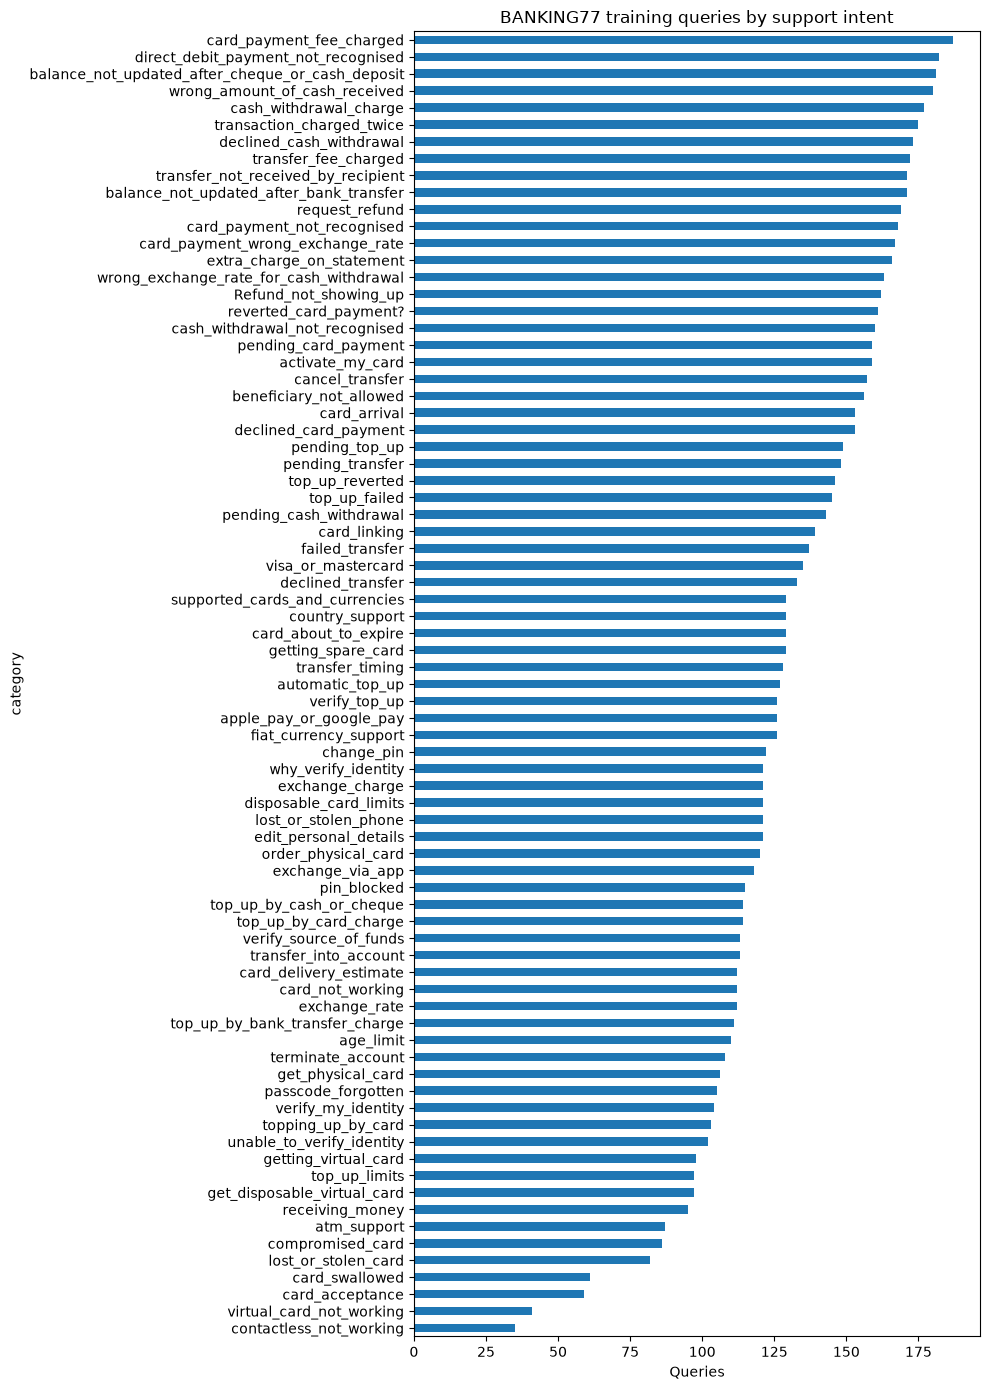

count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: text, dtype: float64


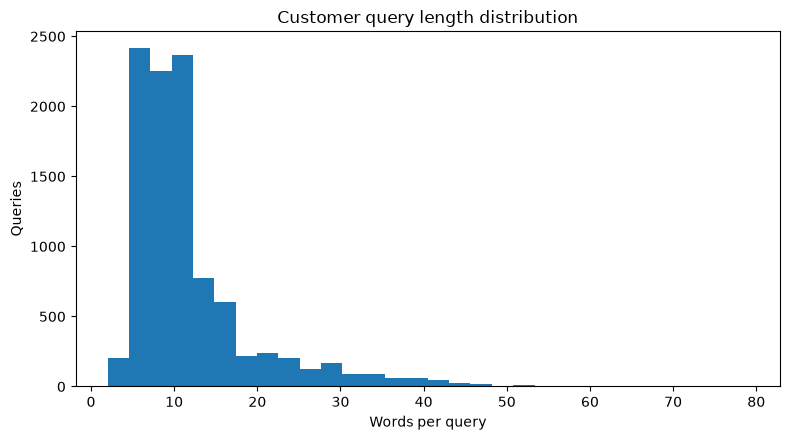

In [3]:
intent_counts = official_train["category"].value_counts()

fig, ax = plt.subplots(figsize=(10, 14))
intent_counts.sort_values().plot(kind="barh", ax=ax)
ax.set_title("BANKING77 training queries by support intent")
ax.set_xlabel("Queries")
plt.tight_layout()
plt.show()

query_lengths = official_train["text"].astype(str).str.split().str.len()
print(query_lengths.describe())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(query_lengths, bins=30)
ax.set_title("Customer query length distribution")
ax.set_xlabel("Words per query")
ax.set_ylabel("Queries")
plt.tight_layout()
plt.show()

## 3. Create validation data without touching the official test set

The original training file is split into:
- model fitting: 80%
- validation: 20%

The official 3,080-query test set remains sealed until final evaluation.

In [4]:
train_df, val_df = train_test_split(
    official_train,
    test_size=0.20,
    stratify=official_train["category"],
    random_state=RANDOM_STATE
)
test_df = official_test.copy()

split_summary = pd.DataFrame({
    "queries":[len(train_df),len(val_df),len(test_df)],
    "classes":[
        train_df["category"].nunique(),
        val_df["category"].nunique(),
        test_df["category"].nunique()
    ]
}, index=["train","validation","official test"])

display(split_summary)
print("Official test examples used during model selection: 0")

,queries,classes
train,8002,77
validation,2001,77
official test,3080,77


Official test examples used during model selection: 0


## 4. Word + character TF-IDF representation

Word n-grams capture issue phrases such as “cash withdrawal” or “card payment”, while character n-grams help with spelling variation and short noisy customer text.

In [5]:
vectorizer = FeatureUnion([
    ("word", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.995,
        sublinear_tf=True,
        max_features=30000,
        stop_words="english"
    )),
    ("char", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3,5),
        min_df=2,
        sublinear_tf=True,
        max_features=30000
    ))
])

X_train = vectorizer.fit_transform(train_df["text"])
X_val = vectorizer.transform(val_df["text"])
X_test = vectorizer.transform(test_df["text"])

print("Training matrix:", X_train.shape)
print("Validation matrix:", X_val.shape)
print("Official test matrix:", X_test.shape)

Training matrix: (8002, 17663)
Validation matrix: (2001, 17663)
Official test matrix: (3080, 17663)


## 5. Fine-grained support routing model

A most-frequent baseline is compared with class-balanced multinomial Logistic Regression across all 77 intents.

In [6]:
y_train = train_df["category"].astype(str)
y_val = val_df["category"].astype(str)
y_test = test_df["category"].astype(str)

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

router = LogisticRegression(
    max_iter=2500,
    class_weight="balanced",
    C=4.0,
    solver="lbfgs"
)
router.fit(X_train, y_train)

def routing_metrics(name, y_true, pred, prob=None, classes=None):
    p,r,f,_ = precision_recall_fscore_support(
        y_true, pred, average="macro", zero_division=0
    )
    result = {
        "model":name,
        "accuracy":accuracy_score(y_true,pred),
        "macro_precision":p,
        "macro_recall":r,
        "macro_F1":f
    }
    if prob is not None:
        result["top3_accuracy"] = top_k_accuracy_score(
            y_true, prob, k=3, labels=classes
        )
    return result

val_baseline_pred = baseline.predict(X_val)
val_prob = router.predict_proba(X_val)
val_pred = router.classes_[val_prob.argmax(axis=1)]

val_results = pd.DataFrame([
    routing_metrics("Most-frequent baseline", y_val, val_baseline_pred),
    routing_metrics("TF-IDF Logistic Regression", y_val, val_pred, val_prob, router.classes_)
]).set_index("model")

display(val_results.style.format({
    "accuracy":"{:.2%}",
    "macro_precision":"{:.2%}",
    "macro_recall":"{:.2%}",
    "macro_F1":"{:.4f}",
    "top3_accuracy":"{:.2%}"
}))

,accuracy,macro_precision,macro_recall,macro_F1,top3_accuracy
model,,,,,
Most-frequent baseline,1.90%,0.02%,1.30%,0.0005,nan%
TF-IDF Logistic Regression,89.01%,89.43%,89.35%,0.8912,97.30%


## 6. Confidence-based human review policy

A production router should not force a confident-looking decision on every query.

The validation set chooses the **lowest confidence threshold that achieves at least 90% accuracy on auto-routed queries**, while maximising coverage. Queries below that threshold are sent to human review.

In [7]:
val_conf = val_prob.max(axis=1)
val_correct = (val_pred == y_val.to_numpy()).astype(int)

threshold_rows = []
for t in np.linspace(0.20,0.95,151):
    auto = val_conf >= t
    if auto.sum() == 0:
        continue
    threshold_rows.append({
        "threshold":t,
        "coverage":auto.mean(),
        "auto_routed_queries":int(auto.sum()),
        "auto_route_accuracy":val_correct[auto].mean()
    })

threshold_table = pd.DataFrame(threshold_rows)
eligible = threshold_table.loc[threshold_table["auto_route_accuracy"] >= 0.90]

if len(eligible):
    chosen = eligible.sort_values(
        ["coverage","auto_route_accuracy"], ascending=False
    ).iloc[0]
else:
    chosen = threshold_table.sort_values(
        ["auto_route_accuracy","coverage"], ascending=False
    ).iloc[0]

review_threshold = float(chosen["threshold"])

display(threshold_table.tail(12).style.format({
    "threshold":"{:.3f}",
    "coverage":"{:.2%}",
    "auto_route_accuracy":"{:.2%}"
}))

print(f"Frozen human-review threshold: {review_threshold:.3f}")
print(f"Validation auto-routing coverage: {chosen['coverage']:.2%}")
print(f"Validation auto-routing accuracy: {chosen['auto_route_accuracy']:.2%}")

,threshold,coverage,auto_routed_queries,auto_route_accuracy
139,0.895,39.43%,789,99.62%
140,0.900,38.18%,764,99.74%
141,0.905,37.08%,742,99.73%
142,0.910,35.78%,716,99.72%
143,0.915,34.58%,692,99.86%
144,0.920,33.43%,669,99.85%
145,0.925,31.53%,631,99.84%
146,0.930,29.89%,598,99.83%
147,0.935,28.14%,563,99.82%
148,0.940,26.54%,531,99.81%


Frozen human-review threshold: 0.200
Validation auto-routing coverage: 96.70%
Validation auto-routing accuracy: 90.80%


## 7. Final evaluation on the untouched official test set

In [8]:
test_prob = router.predict_proba(X_test)
test_pred = router.classes_[test_prob.argmax(axis=1)]
test_conf = test_prob.max(axis=1)

test_result = routing_metrics(
    "BANKING77 ticket router",
    y_test,
    test_pred,
    test_prob,
    router.classes_
)

auto = test_conf >= review_threshold
auto_accuracy = (
    (test_pred[auto] == y_test.to_numpy()[auto]).mean()
    if auto.sum() else np.nan
)

test_result["auto_route_coverage"] = auto.mean()
test_result["auto_route_accuracy"] = auto_accuracy
test_result["human_review_rate"] = 1-auto.mean()

display(pd.DataFrame([test_result]).set_index("model").style.format({
    "accuracy":"{:.2%}",
    "macro_precision":"{:.2%}",
    "macro_recall":"{:.2%}",
    "macro_F1":"{:.4f}",
    "top3_accuracy":"{:.2%}",
    "auto_route_coverage":"{:.2%}",
    "auto_route_accuracy":"{:.2%}",
    "human_review_rate":"{:.2%}"
}))

print(classification_report(y_test,test_pred,zero_division=0))

,accuracy,macro_precision,macro_recall,macro_F1,top3_accuracy,auto_route_coverage,auto_route_accuracy,human_review_rate
model,,,,,,,,
BANKING77 ticket router,89.35%,89.75%,89.35%,0.8935,97.01%,96.72%,91.17%,3.28%


                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.97      0.90      0.94        40
                                activate_my_card       0.97      0.93      0.95        40
                                       age_limit       0.98      1.00      0.99        40
                         apple_pay_or_google_pay       0.98      1.00      0.99        40
                                     atm_support       0.97      0.95      0.96        40
                                automatic_top_up       0.97      0.90      0.94        40
         balance_not_updated_after_bank_transfer       0.73      0.80      0.76        40
balance_not_updated_after_cheque_or_cash_deposit       0.93      0.95      0.94        40
                         beneficiary_not_allowed       1.00      0.82      0.90        40
                                 cancel_transfer       0.97      0.97      0.97        40
         

## 8. Error analysis — which support intents are hardest to separate?

In [9]:
errors = pd.DataFrame({
    "text":test_df["text"].to_numpy(),
    "actual":y_test.to_numpy(),
    "predicted":test_pred,
    "confidence":test_conf
})
errors["correct"] = errors["actual"] == errors["predicted"]

per_intent = (
    errors.groupby("actual")
    .agg(
        queries=("correct","size"),
        accuracy=("correct","mean"),
        avg_confidence=("confidence","mean")
    )
    .sort_values("accuracy")
)

print("Hardest 15 intents:")
display(per_intent.head(15).style.format({
    "accuracy":"{:.2%}",
    "avg_confidence":"{:.2%}"
}))

print("High-confidence mistakes:")
display(
    errors.loc[~errors["correct"]]
    .sort_values("confidence",ascending=False)
    .head(20)
)

Hardest 15 intents:


,queries,accuracy,avg_confidence
actual,,,
top_up_failed,40,72.50%,63.68%
virtual_card_not_working,40,72.50%,69.48%
pending_transfer,40,75.00%,65.73%
fiat_currency_support,40,75.00%,74.65%
topping_up_by_card,40,77.50%,62.59%
balance_not_updated_after_bank_transfer,40,80.00%,75.32%
declined_transfer,40,80.00%,76.99%
card_payment_not_recognised,40,80.00%,61.79%
top_up_reverted,40,80.00%,69.46%


High-confidence mistakes:


,text,actual,predicted,confidence,correct
2711,My transfer is pending.,balance_not_updated_after_bank_transfer,pending_transfer,0.990989,False
2637,how many transactions can i make with a disposable card,get_disposable_virtual_card,disposable_card_limits,0.967633,False
2503,can I have a non virtual card?,order_physical_card,getting_virtual_card,0.930413,False
11,How long does a card delivery take?,card_arrival,card_delivery_estimate,0.928947,False
2622,how does a virtual card work,get_disposable_virtual_card,virtual_card_not_working,0.928931,False
2763,Where do I find the exchange rate?,exchange_charge,exchange_rate,0.915914,False
2048,how long dies it take for transfers to reflect on my balance,transfer_timing,balance_not_updated_after_bank_transfer,0.915631,False
522,Will you reinstate my PIN?,pin_blocked,get_physical_card,0.913712,False
2338,How do I top up my card?,transfer_into_account,topping_up_by_card,0.907464,False
2530,I cannot use my disposable virtual card.,virtual_card_not_working,get_disposable_virtual_card,0.867601,False


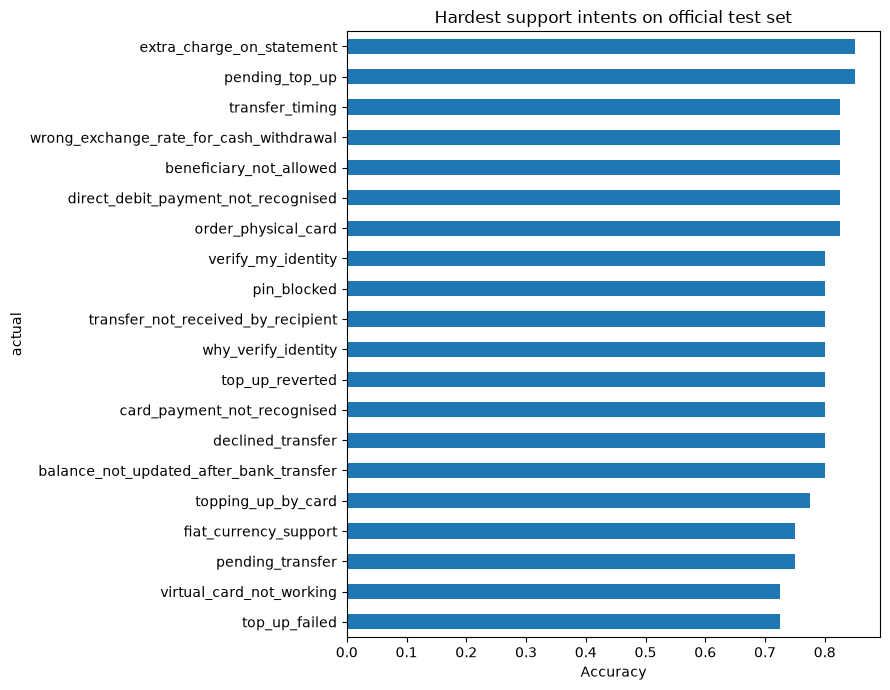

In [10]:
top20 = per_intent.head(20).sort_values("accuracy")
fig, ax = plt.subplots(figsize=(9, 7))
top20["accuracy"].plot(kind="barh",ax=ax)
ax.set_title("Hardest support intents on official test set")
ax.set_xlabel("Accuracy")
plt.tight_layout()
plt.show()

## 9. Semantic retrieval — find similar historical support queries

The router can also act as an agent-assist retrieval layer by surfacing semantically similar training examples.

In [11]:
word_vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.995,
    sublinear_tf=True,
    stop_words="english",
    max_features=25000
)
W_train = word_vectorizer.fit_transform(train_df["text"])
W_test = word_vectorizer.transform(test_df["text"])

def similar_queries(test_position, n=6):
    sims = cosine_similarity(W_test[test_position], W_train).ravel()
    idx = np.argsort(-sims)[:n]
    out = train_df.iloc[idx][["text","category"]].copy()
    out["similarity"] = sims[idx]
    return out.sort_values("similarity",ascending=False)

example_position = 0
print("Incoming query:")
display(test_df.iloc[[example_position]])
print("\nNearest historical queries:")
display(similar_queries(example_position,6))

Incoming query:


,text,category
0,How do I locate my card?,card_arrival



Nearest historical queries:


,text,category,similarity
3063,How can I locate the virtual card?,getting_virtual_card,0.771501
4016,Where can I locate my card PIN?,get_physical_card,0.728149
2823,The recipient can not locate funds.,transfer_not_received_by_recipient,0.647711
4025,Where can I locate my PIN at?,get_physical_card,0.614146
4051,Can you tell me how to locate my PIN?,get_physical_card,0.576401
4053,How do I locate my PIN now that I have my card?,get_physical_card,0.554778


## 10. Unsupervised issue-family discovery

The 77 fine-grained labels are useful for routing, but operations leaders often need a smaller number of high-level issue families. Truncated SVD + K-Means discovers those broader themes without using the labels during clustering.

,k,silhouette
0,6,0.027087
1,7,0.069353
2,8,0.053276
3,9,0.094564
4,10,0.073183
5,11,0.084351
6,12,0.089107


Selected issue-family clusters: 9


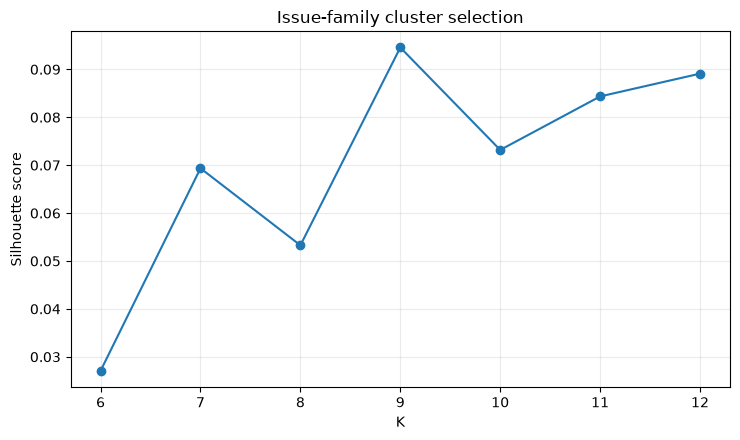

In [12]:
all_queries = pd.concat([
    train_df[["text","category"]],
    val_df[["text","category"]],
    test_df[["text","category"]]
], ignore_index=True)

cluster_vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=3,
    max_df=0.98,
    stop_words="english",
    max_features=12000
)
C = cluster_vectorizer.fit_transform(all_queries["text"])

svd = TruncatedSVD(n_components=60, random_state=RANDOM_STATE)
Z = svd.fit_transform(C)

cluster_scores=[]
for k in range(6,13):
    km = KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=20)
    labels = km.fit_predict(Z)
    score = silhouette_score(
        Z,labels,sample_size=min(4000,len(Z)),random_state=RANDOM_STATE
    )
    cluster_scores.append((k,score))

cluster_score_df = pd.DataFrame(cluster_scores,columns=["k","silhouette"])
best_k = int(cluster_score_df.sort_values("silhouette",ascending=False).iloc[0]["k"])

kmeans = KMeans(n_clusters=best_k,random_state=RANDOM_STATE,n_init=30)
all_queries["cluster"] = kmeans.fit_predict(Z)

display(cluster_score_df)
print("Selected issue-family clusters:",best_k)

fig, ax = plt.subplots(figsize=(7.5,4.5))
ax.plot(cluster_score_df["k"],cluster_score_df["silhouette"],marker="o")
ax.set_title("Issue-family cluster selection")
ax.set_xlabel("K")
ax.set_ylabel("Silhouette score")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

,queries,dominant_intent,dominant_intent_share,top_intents
cluster,,,,
0,445,change_pin,35.73%,"change_pin, get_physical_card, pin_blocked, edit_personal_details, declined_cash_withdrawal"
1,364,card_payment_wrong_exchange_rate,44.23%,"card_payment_wrong_exchange_rate, wrong_exchange_rate_for_cash_withdrawal, exchange_rate, exchange_charge, exchange_via_app"
2,2471,activate_my_card,7.77%,"activate_my_card, card_arrival, card_linking, card_about_to_expire, card_not_working"
3,1249,pending_transfer,11.85%,"pending_transfer, failed_transfer, balance_not_updated_after_bank_transfer, transfer_timing, beneficiary_not_allowed"
4,765,pending_cash_withdrawal,17.39%,"pending_cash_withdrawal, cash_withdrawal_charge, cash_withdrawal_not_recognised, wrong_amount_of_cash_received, balance_not_updated_after_cheque_or_cash_deposit"
5,6542,request_refund,3.19%,"request_refund, extra_charge_on_statement, Refund_not_showing_up, top_up_reverted, pending_top_up"
6,330,getting_virtual_card,39.39%,"getting_virtual_card, get_disposable_virtual_card, virtual_card_not_working, disposable_card_limits, order_physical_card"
7,705,pending_card_payment,22.70%,"pending_card_payment, reverted_card_payment?, card_payment_not_recognised, declined_card_payment, direct_debit_payment_not_recognised"
8,212,verify_top_up,30.19%,"verify_top_up, verify_my_identity, why_verify_identity, unable_to_verify_identity, verify_source_of_funds"


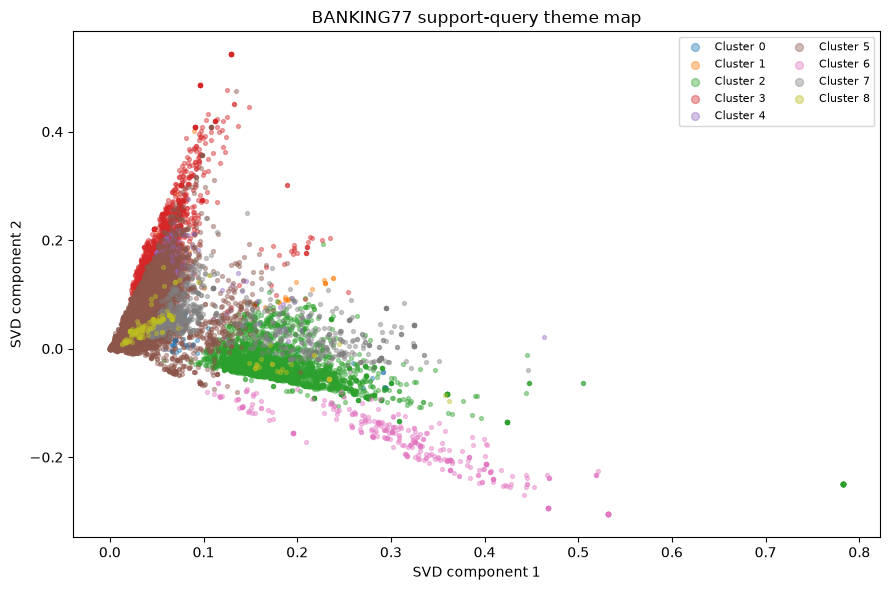

In [13]:
cluster_report_rows=[]
for cluster_id,g in all_queries.groupby("cluster"):
    top_intents = g["category"].value_counts().head(5)
    cluster_report_rows.append({
        "cluster":cluster_id,
        "queries":len(g),
        "dominant_intent":top_intents.index[0],
        "dominant_intent_share":top_intents.iloc[0]/len(g),
        "top_intents":", ".join(top_intents.index.tolist())
    })

cluster_report = pd.DataFrame(cluster_report_rows).set_index("cluster")
display(cluster_report.style.format({
    "dominant_intent_share":"{:.2%}"
}))

svd2 = TruncatedSVD(n_components=2,random_state=RANDOM_STATE)
Z2 = svd2.fit_transform(C)

fig, ax = plt.subplots(figsize=(9,6))
for cluster_id in sorted(all_queries["cluster"].unique()):
    mask = all_queries["cluster"].to_numpy() == cluster_id
    ax.scatter(
        Z2[mask,0],Z2[mask,1],
        s=8,alpha=0.4,label=f"Cluster {cluster_id}"
    )
ax.set_title("BANKING77 support-query theme map")
ax.set_xlabel("SVD component 1")
ax.set_ylabel("SVD component 2")
ax.legend(markerscale=2,ncol=2,fontsize=8)
plt.tight_layout()
plt.show()

## 11. Operational urgency policy

BANKING77 does not contain SLA timestamps or human-labelled priority. Rather than invent a target, the notebook applies an **explicit business policy** to predicted intents.

Security, unrecognised-transaction, stolen-card and cash-access issues are treated as higher urgency. This is a deterministic policy layer and is clearly separated from the learned routing model.

In [14]:
CRITICAL_INTENTS = {
    "card_payment_not_recognised",
    "cash_withdrawal_not_recognised",
    "direct_debit_payment_not_recognised",
    "compromised_card",
    "lost_or_stolen_card",
    "lost_or_stolen_phone",
    "card_swallowed"
}

HIGH_INTENTS = {
    "declined_cash_withdrawal",
    "pending_cash_withdrawal",
    "cash_withdrawal_charge",
    "wrong_amount_of_cash_received",
    "wrong_exchange_rate_for_cash_withdrawal",
    "declined_card_payment",
    "pending_card_payment",
    "card_not_working",
    "pin_blocked",
    "declined_transfer",
    "failed_transfer",
    "pending_transfer",
    "transfer_not_received_by_recipient",
    "transaction_charged_twice",
    "unable_to_verify_identity"
}

def support_urgency(intent):
    intent = str(intent)
    if intent in CRITICAL_INTENTS:
        return "Critical"
    if intent in HIGH_INTENTS:
        return "High"
    return "Standard"

available_intents = set(official_train["category"].unique())
print("Critical policy intents present:", len(CRITICAL_INTENTS & available_intents))
print("High policy intents present:", len(HIGH_INTENTS & available_intents))

predicted_tiers = pd.Series(test_pred).map(support_urgency)
display(predicted_tiers.value_counts().to_frame("official-test queries"))

Critical policy intents present: 7
High policy intents present: 15


,official-test queries
Standard,2204
High,602
Critical,274


## 12. PII-free operational triage queue

The score combines:
- intent-routing confidence;
- human-review status;
- business-defined urgency tier.

No personal or demographic data is present in BANKING77.

In [15]:
tier_weight = {"Standard":0.35,"High":0.75,"Critical":1.00}

queue = test_df[["text","category"]].copy().reset_index(drop=True)
queue["predicted_intent"] = test_pred
queue["route_confidence"] = test_conf
queue["human_review"] = test_conf < review_threshold
queue["urgency_tier"] = [support_urgency(x) for x in test_pred]
queue["urgency_weight"] = queue["urgency_tier"].map(tier_weight)
queue["triage_score"] = (
    0.60 * queue["urgency_weight"]
    + 0.25 * (1-queue["route_confidence"])
    + 0.15 * queue["human_review"].astype(float)
)
queue["ticket_key"] = [f"B77-{i+1:04d}" for i in range(len(queue))]

queue = queue.sort_values(
    ["urgency_weight","human_review","triage_score"],
    ascending=[False,False,False]
).reset_index(drop=True)

print("Top 30 operational triage queries:")
display(queue[[
    "ticket_key","text","predicted_intent",
    "route_confidence","human_review","urgency_tier","triage_score"
]].head(30).style.format({
    "route_confidence":"{:.2%}",
    "triage_score":"{:.3f}"
}))

queue.to_csv("banking77_support_triage_queue.csv",index=False)
per_intent.to_csv("banking77_intent_test_performance.csv")
cluster_report.to_csv("banking77_issue_family_clusters.csv")
print("Operational artefacts exported.")

Top 30 operational triage queries:


,ticket_key,text,predicted_intent,route_confidence,human_review,urgency_tier,triage_score
0,B77-0340,How do I make sure I don't run out of money on my card while traveling?,direct_debit_payment_not_recognised,7.41%,True,Critical,0.981
1,B77-1513,I am concerned about the security in my account and would like to make a dispute.,direct_debit_payment_not_recognised,10.29%,True,Critical,0.974
2,B77-0990,areas card is accpeted,lost_or_stolen_card,13.06%,True,Critical,0.967
3,B77-1517,Someone has taken my money and I don't know who,cash_withdrawal_not_recognised,13.36%,True,Critical,0.967
4,B77-2746,I need to cancel my card that got stolen a little while ago. Someone has already taken some money out and I don't want them to take anymore. Can you please do that?,cash_withdrawal_not_recognised,14.62%,True,Critical,0.963
5,B77-1348,Cannot access my top up.,lost_or_stolen_phone,14.66%,True,Critical,0.963
6,B77-1665,I believe I left my smartphone at the hotel I was staying at.,lost_or_stolen_phone,17.48%,True,Critical,0.956
7,B77-2739,I'm unsure of a withdrawl in my statement.,cash_withdrawal_not_recognised,17.61%,True,Critical,0.956
8,B77-1117,I think there has been a purchase made that wasn't by me.,compromised_card,17.67%,True,Critical,0.956
9,B77-1922,How do I retrieve my card from the machine?,card_swallowed,17.88%,True,Critical,0.955


Operational artefacts exported.


## 13. Executive summary

In [16]:
print(f"""
AI SUPPORT-TICKET INTELLIGENCE SUMMARY
--------------------------------------
Dataset: BANKING77
Total labelled customer queries: {len(official_train)+len(official_test):,}
Fine-grained intents: {official_train['category'].nunique()}
Official test queries: {len(test_df):,}

Demographic fields available: NONE
Names/emails/PII available: NONE

Routing accuracy: {test_result['accuracy']:.2%}
Routing macro F1: {test_result['macro_F1']:.4f}
Top-3 routing accuracy: {test_result['top3_accuracy']:.2%}

Frozen human-review threshold: {review_threshold:.3f}
Auto-route coverage: {test_result['auto_route_coverage']:.2%}
Auto-route accuracy: {test_result['auto_route_accuracy']:.2%}
Human-review rate: {test_result['human_review_rate']:.2%}

Discovered broad issue-family clusters: {best_k}

The final system converts support text into a fine-grained intent route,
confidence-aware human handoff, similar-case retrieval, broader issue
families and a PII-free operational triage queue.
""")


AI SUPPORT-TICKET INTELLIGENCE SUMMARY
--------------------------------------
Dataset: BANKING77
Total labelled customer queries: 13,083
Fine-grained intents: 77
Official test queries: 3,080

Demographic fields available: NONE
Names/emails/PII available: NONE

Routing accuracy: 89.35%
Routing macro F1: 0.8935
Top-3 routing accuracy: 97.01%

Frozen human-review threshold: 0.200
Auto-route coverage: 96.72%
Auto-route accuracy: 91.17%
Human-review rate: 3.28%

Discovered broad issue-family clusters: 9

The final system converts support text into a fine-grained intent route,
confidence-aware human handoff, similar-case retrieval, broader issue
families and a PII-free operational triage queue.



### Production roadmap
- fine-tune a compact transformer and compare against this strong sparse baseline;
- calibration and out-of-distribution intent detection;
- multilingual routing;
- retrieval from approved knowledge-base content;
- agent skill / workload-aware assignment;
- true SLA timestamps and service-level optimisation;
- feedback loops from agent corrections;
- drift monitoring as products and policies change;
- online measurement with first-contact resolution, handle time and CSAT.

### Interview defence
**“My first support-ticket dataset produced near-random labels, so I rejected it rather than dressing up weak metrics. I rebuilt the project on BANKING77, preserved the official test set, added word and character NLP features, confidence-based abstention, semantic retrieval, issue-family clustering and an operational triage layer. That data-quality decision is part of the project, not something I hide.”**